# Motion deblurring with events: CMax, EDI and EFNet

Deblurs frames of the REBlur dataset (real blurry DAVIS frames with ground truth) with three event-based methods: CMax + Richardson-Lucy deconvolution, EDI (Pan et al., CVPR 2019) and EFNet (Sun et al., ECCV 2022). Sections 3 to 5 run each method on three samples, section 6 evaluates the test split, and section 7 is a placeholder for our own DAVIS346 data.

$$\log I(\mathbf{x}, t_k) - \log I(\mathbf{x}, t_k - \Delta t_k) = p_k\, c$$

$I$: intensity, $\mathbf{x}$: pixel, $t_k$: event time, $\Delta t_k$: time since the previous event at that pixel, $p_k = \pm 1$: polarity, $c$: contrast threshold.

## 1. Setup and data

In [1]:
import os, sys
if "google.colab" in sys.modules:
    REPO = "/content/event-perception"
    if not os.path.exists(REPO):
        !git clone https://github.com/allusson/event-perception.git {REPO}
    %cd {REPO}
    !pip install -q -e .
    sys.path.insert(0, REPO)
else:
    # local: assumes `pip install -e ".[deblur]"` was run from the repo root
    os.chdir(os.path.dirname(os.path.abspath("")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

The next cell imports `evcam`, downloads REBlur with `scripts/download_data.py reblur` (about 1.2 GB download, 8 GB unpacked; skipped if already there) and checks that the EFNet checkpoint exists. Requirements: `pip install -e ".[deblur]"` (torch, einops) and `weights/EFNet-REBlur.pth`, downloaded by hand from the Google Drive link in the [EFNet README](https://github.com/AHupuJR/EFNet) (on Colab, upload it into `event-perception/weights/`).

In [2]:
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")   # must be set before torch is imported
if "google.colab" in sys.modules:
    %pip install -q einops

import warnings
import numpy as np
import matplotlib.pyplot as plt

from evcam.io import list_reblur, load_reblur_sample, load_aedat4, frames_look_accumulated
from evcam.representations import scer, scer_mask, event_image
from evcam.deblur import (edi_deblur, edi_select_c, edi_oracle_c, cmax_deblur, efnet_deblur, pick_device)
from evcam.efnet_arch import load_efnet
from evcam.deblur_eval import fit_fixed_c, evaluate_reblur
from evcam.metrics import psnr, ssim
from evcam.viz import show_images, busiest_crop

!{sys.executable} scripts/download_data.py reblur
WEIGHTS = "weights/EFNet-REBlur.pth"
assert os.path.exists(WEIGHTS), f"{WEIGHTS} is missing: download EFNet-REBlur.pth from the EFNet repo's Google Drive link"

REBlur -> data/reblur
  have     REBlur.zip
  have     REBlur_rawevents.zip
done: ['.unzipped_REBlur.zip', '.unzipped_REBlur_rawevents.zip', 'REBlur', 'REBlur.zip', 'REBlur_rawevents', 'REBlur_rawevents.zip', 'eval_test.npz', 'fixed_c_train.npz']


## 2. REBlur samples

Loads three test samples with `load_reblur_sample` (a line, a circle and a camera-motion sequence) and shows the blurry frame, the ground truth and the events during the exposure. The yellow box is the zoom region used in later figures, placed where the event density is highest.

REBlur: 486 train and 903 test samples
1-3-line-100 #3: frame (260, 320), exposure 46 ms, 47,232 events in the exposure, blurry input PSNR 23.86 dB
1-2-circle #28: frame (260, 320), exposure 46 ms, 44,893 events in the exposure, blurry input PSNR 28.02 dB
1-4-r-200 #3: frame (260, 320), exposure 46 ms, 57,612 events in the exposure, blurry input PSNR 27.82 dB


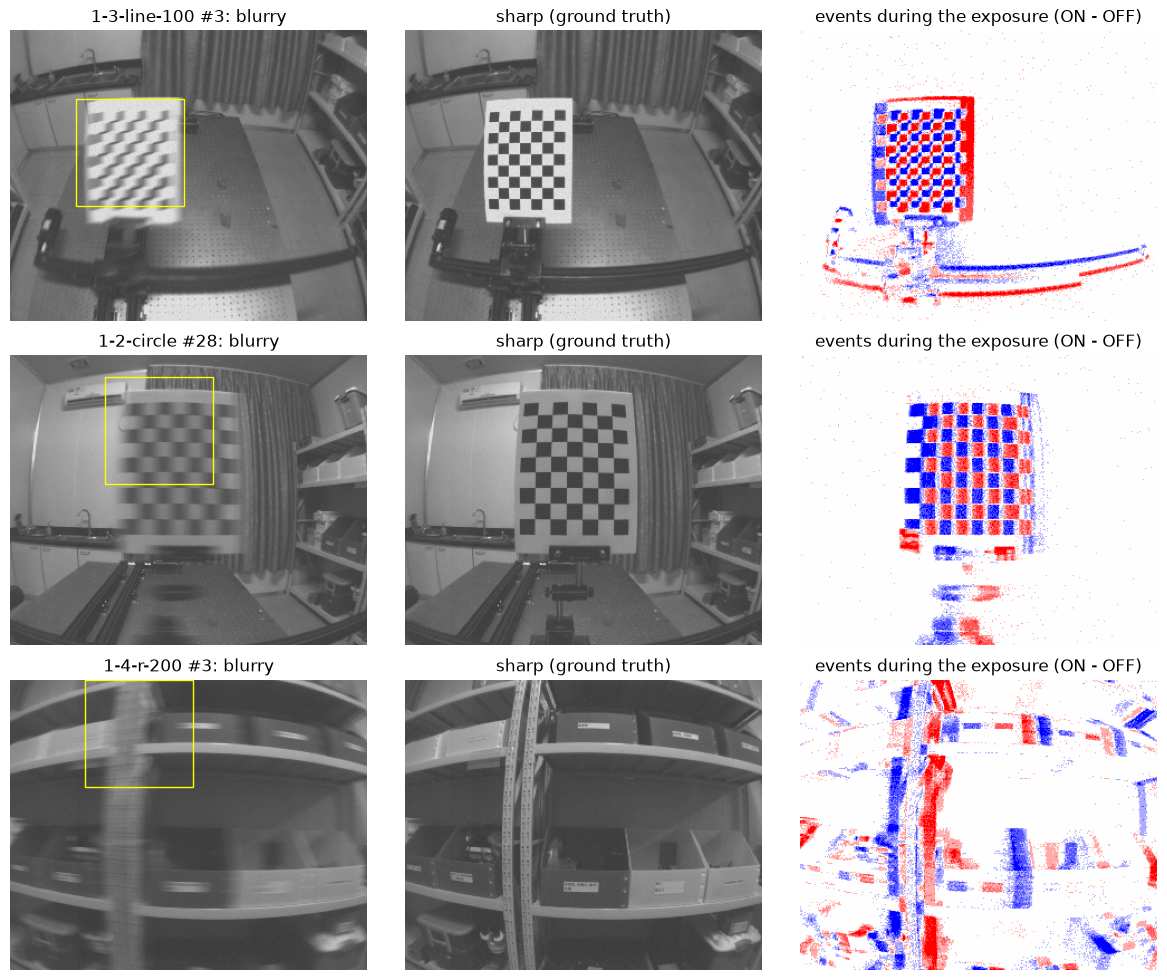

In [3]:
test_samples = list_reblur("test")
print(f"REBlur: {len(list_reblur('train'))} train and {len(test_samples)} test samples")

SAMPLES = [('1-3-line-100', 3), ('1-2-circle', 28), ('1-4-r-200', 3)]
data = [load_reblur_sample(seq, i) for seq, i in SAMPLES]
for (seq, i), d in zip(SAMPLES, data):
    print(f"{seq} #{i}: frame {d['blurry'].shape}, exposure {(d['t_end'] - d['t_begin']) / 1e3:.0f} ms, "
          f"{len(d['events']):,} events in the exposure, blurry input PSNR {psnr(d['blurry'], d['sharp']):.2f} dB")

H, W = data[0]["blurry"].shape
crops = [busiest_crop(d["events"], (H, W)) for d in data]   # zoom region per sample: where the events are

fig, ax = plt.subplots(len(data), 3, figsize=(12, 3.3 * len(data)))
for r, ((seq, i), d, (y0, y1, x0, x1)) in enumerate(zip(SAMPLES, data, crops)):
    ax[r, 0].imshow(d["blurry"], cmap="gray", vmin=0, vmax=1); ax[r, 0].set_title(f"{seq} #{i}: blurry")
    ax[r, 0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="yellow", lw=1))
    ax[r, 1].imshow(d["sharp"], cmap="gray", vmin=0, vmax=1); ax[r, 1].set_title("sharp (ground truth)")
    ax[r, 2].imshow(event_image(d["events"], (W, H, 2)), cmap="bwr", vmin=-3, vmax=3)
    ax[r, 2].set_title("events during the exposure (ON - OFF)")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

Computes SCER (Symmetric Cumulative Event Representation), EFNet's 6-channel event input, from raw events with `evcam.representations.scer` and compares it with the SCER stored in REBlur.

$$S_k(\mathbf{x}) = -\sum_{e_k \le t_i < t_\text{mid}} p_i \quad (k < n/2), \qquad S_k(\mathbf{x}) = +\sum_{t_\text{mid} \le t_i < e_{k+1}} p_i \quad (k \ge n/2)$$

$S_k$: channel $k$ of $n = 6$, $p_i = \pm 1$, $t_i$: polarity and time of the events at pixel $\mathbf{x}$, $e_k = t_0 + kT/n$: slice edges, $t_0$, $T$: exposure start and duration, $t_\text{mid} = t_0 + T/2$.

our SCER vs stored: correlation 0.9982, 99.86% of voxels identical, max difference 1 event(s)


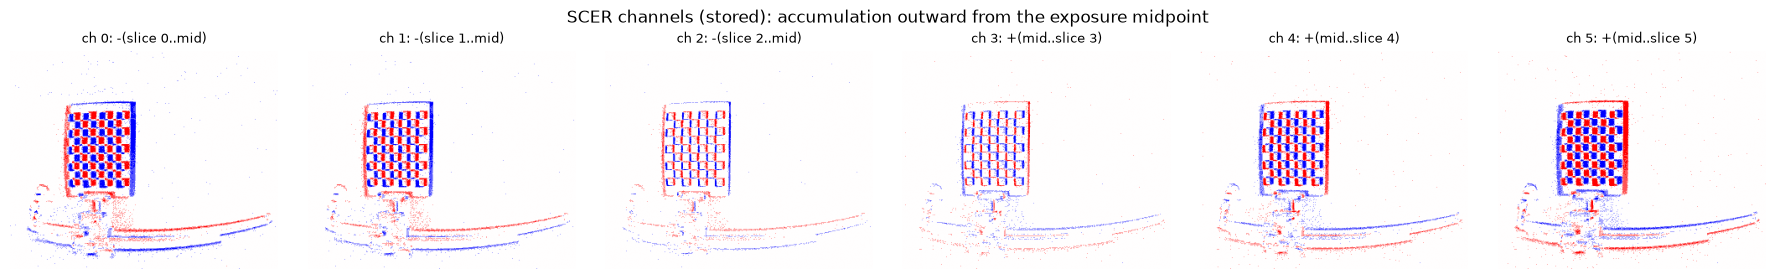

In [4]:
d = data[0]
own = scer(d["events"], d["t_begin"], d["t_end"], (H, W))
stored = d["scer"]
print(f"our SCER vs stored: correlation {np.corrcoef(own.ravel(), stored.ravel())[0, 1]:.4f}, "
      f"{np.mean(own == stored):.2%} of voxels identical, max difference {np.abs(own - stored).max():.0f} event(s)")

fig, ax = plt.subplots(1, 6, figsize=(18, 2.8))
for k in range(6):
    ax[k].imshow(stored[k], cmap="bwr", vmin=-3, vmax=3); ax[k].axis("off")
    ax[k].set_title(f"ch {k}: " + ("-(slice %d..mid)" % k if k < 3 else "+(mid..slice %d)" % k), fontsize=9)
fig.suptitle("SCER channels (stored): accumulation outward from the exposure midpoint"); plt.tight_layout(); plt.show()

## 3. CMax + Richardson-Lucy deconvolution

`cmax_deblur` estimates one blur vector per 64 px patch with `patchwise_flow` (notebook 02) on the events in the exposure, builds a linear motion PSF from it and deconvolves each tile with Richardson-Lucy (10 iterations). Tiles are blended with Hann windows, and the result is kept only near pixels that fired events.

$$k_{\mathbf{d}}(\mathbf{x}) = \int_{-1/2}^{1/2} \delta(\mathbf{x} - s\,\mathbf{d})\,ds, \qquad B = L * k_{\mathbf{d}}$$

$\mathbf{d}$: blur vector (CMax flow in pixels per exposure), $k_{\mathbf{d}}$: linear motion PSF, a centred line segment with unit sum, $B$: blurry frame, $L$: sharp frame, $*$: convolution.

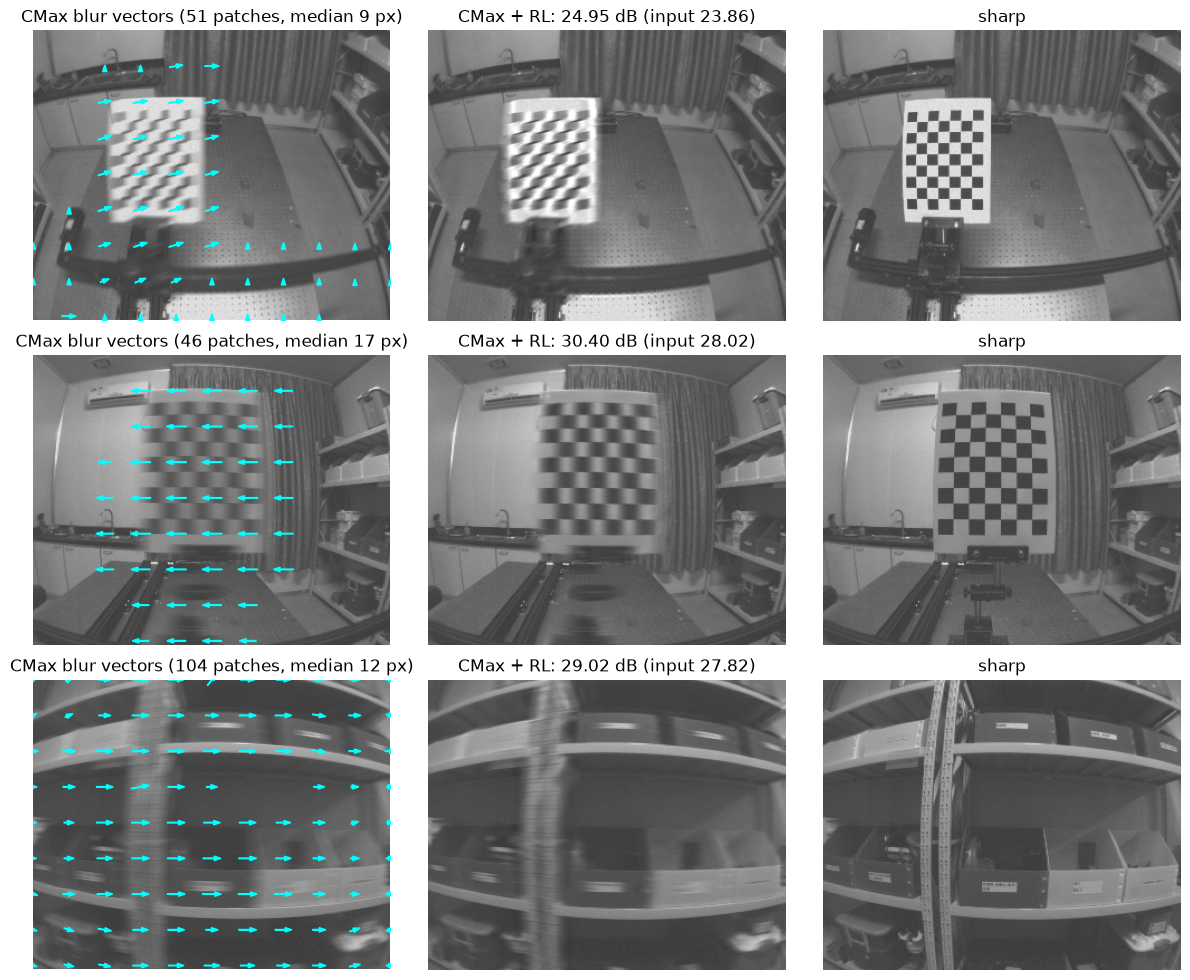

In [5]:
cmax_out = []
fig, ax = plt.subplots(len(data), 3, figsize=(12, 3.3 * len(data)))
for r, d in enumerate(data):
    out, info = cmax_deblur(d["blurry"], d["events"], d["t_begin"], d["t_end"], return_info=True)
    cmax_out.append(out)
    ax[r, 0].imshow(d["blurry"], cmap="gray", vmin=0, vmax=1)
    for x0, y0, dx, dy in info["tiles"]:     # one arrow per patch: the blur vector, centred on the patch
        ax[r, 0].arrow(x0 + 32 - dx / 2, y0 + 32 - dy / 2, dx, dy, color="cyan", width=0.6, head_width=4,
                       length_includes_head=True)
    ax[r, 0].set_xlim(0, W); ax[r, 0].set_ylim(H, 0)
    lengths = [np.hypot(dx, dy) for _, _, dx, dy in info["tiles"]]
    ax[r, 0].set_title(f"CMax blur vectors ({len(lengths)} patches, median {np.median(lengths) if lengths else 0:.0f} px)")
    ax[r, 1].imshow(out, cmap="gray", vmin=0, vmax=1)
    ax[r, 1].set_title(f"CMax + RL: {psnr(out, d['sharp']):.2f} dB (input {psnr(d['blurry'], d['sharp']):.2f})")
    ax[r, 2].imshow(d["sharp"], cmap="gray", vmin=0, vmax=1); ax[r, 2].set_title("sharp")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

## 4. EDI: Event-based Double Integral

`edi_deblur` divides the blurry frame by the per-pixel integral below to get the sharp frame at mid-exposure. The contrast threshold is set in two ways: `edi_select_c` minimizes $J(c)$ without ground truth, and `edi_oracle_c` maximizes PSNR against the ground truth (an upper bound, not a usable method).

$$B(\mathbf{x}) = L(\mathbf{x}, t_\text{ref}) \cdot \frac{1}{T}\int_{t_0}^{t_0+T} \exp\big(c\,E(\mathbf{x}, t)\big)\,dt$$

$B$: blurry frame, $L(\mathbf{x}, t_\text{ref})$: sharp frame at the reference time (exposure midpoint), $t_0$, $T$: exposure start and duration, $c$: contrast threshold, $E(\mathbf{x}, t)$: signed event count at $\mathbf{x}$ between $t_\text{ref}$ and $t$.

$$J(c) = \frac{\mathrm{TV}(L_c)}{\mathrm{TV}(B)} - \lambda\,\operatorname{corr}\big(\lvert \nabla L_c \rvert,\ M\big)$$

$L_c$: EDI result for threshold $c$, $\mathrm{TV}$: total variation, $M$: event edge map (`event_edge_map`), $\lambda = 0.25$: weight, tuned on the REBlur train split.

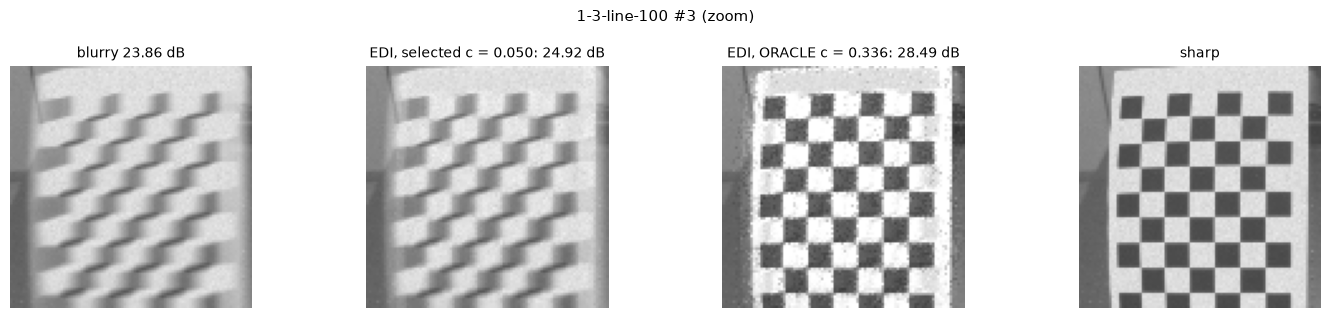

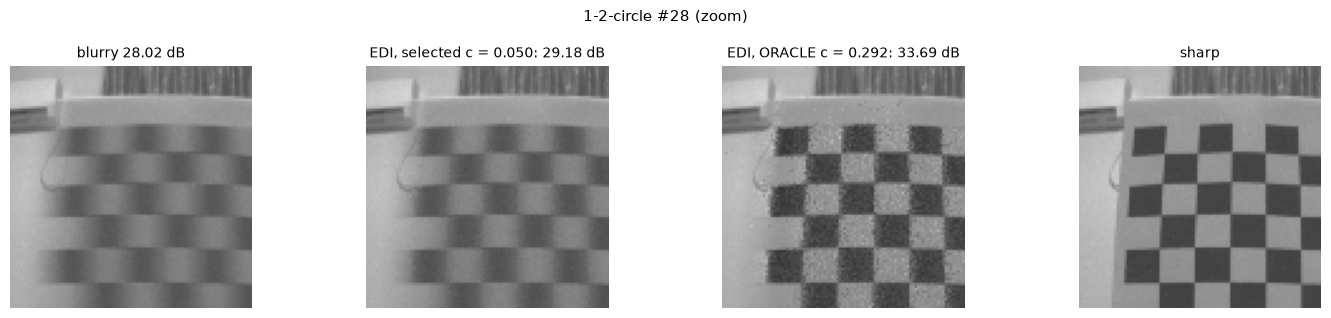

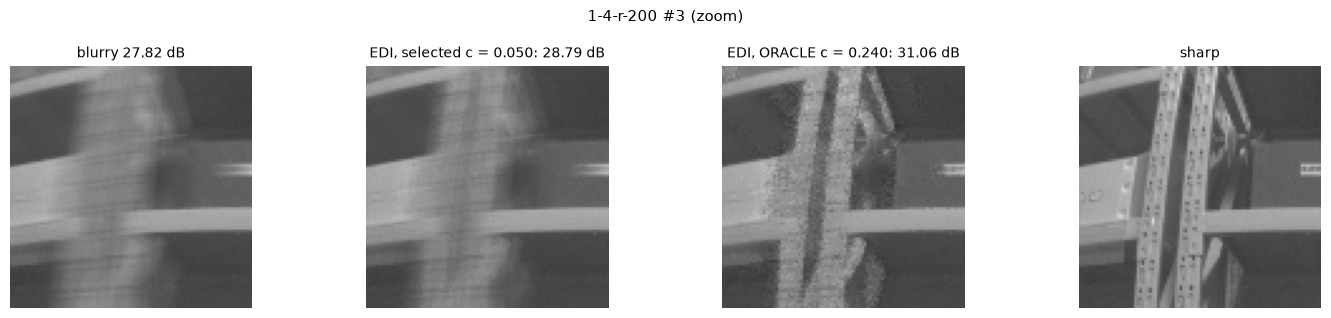

In [6]:
edi_sel, edi_orc, c_sel, c_orc, curves = [], [], [], [], []
for d in data:
    args = (d["events"], d["t_begin"], d["t_end"])
    c1, sel_curve = edi_select_c(d["blurry"], *args)                 # no ground truth
    c2, orc_curve = edi_oracle_c(d["blurry"], d["sharp"], *args)     # ORACLE: uses the ground truth
    c_sel.append(c1); c_orc.append(c2); curves.append((sel_curve, orc_curve))
    edi_sel.append(edi_deblur(d["blurry"], *args, c1)); edi_orc.append(edi_deblur(d["blurry"], *args, c2))

for r, (d, crop) in enumerate(zip(data, crops)):
    imgs = [d["blurry"], edi_sel[r], edi_orc[r], d["sharp"]]
    titles = [f"blurry {psnr(imgs[0], d['sharp']):.2f} dB",
              f"EDI, selected c = {c_sel[r]:.3f}: {psnr(imgs[1], d['sharp']):.2f} dB",
              f"EDI, ORACLE c = {c_orc[r]:.3f}: {psnr(imgs[2], d['sharp']):.2f} dB", "sharp"]
    show_images(imgs, titles, crop=crop, suptitle=f"{SAMPLES[r][0]} #{SAMPLES[r][1]} (zoom)"); plt.show()

Plots the selection objective $J(c)$ and the PSNR against ground truth as functions of $c$ for each sample, then the EDI result for a sweep of $c$ on the first sample.

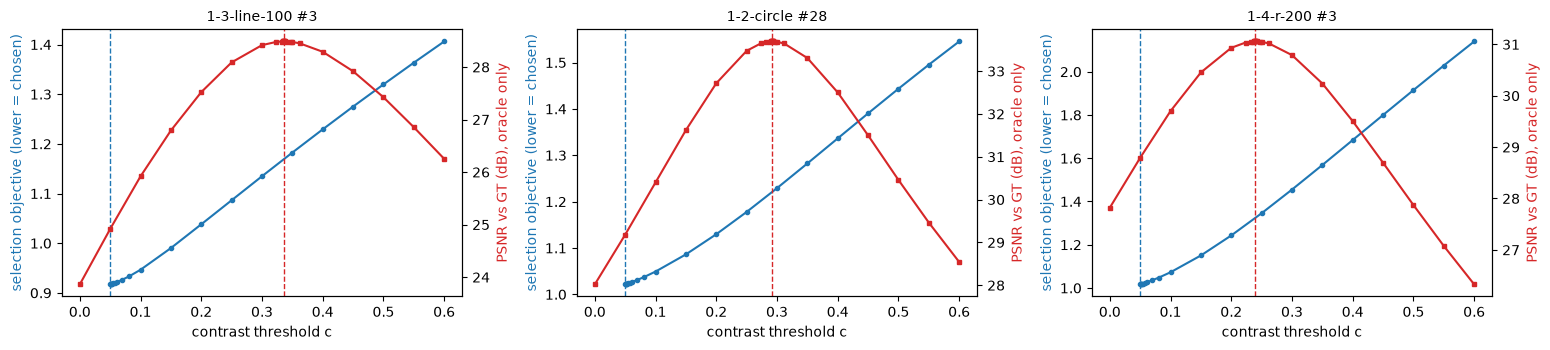

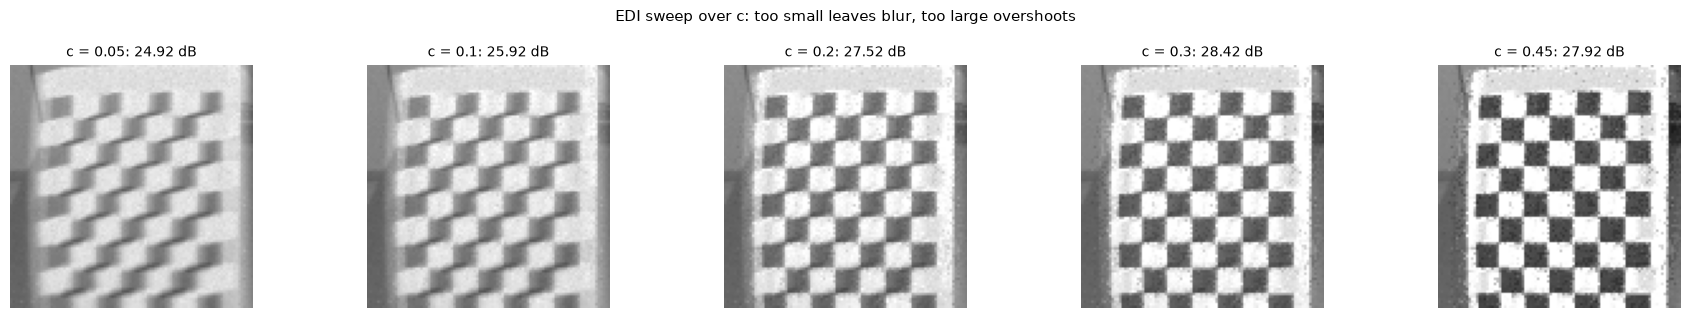

In [7]:
fig, ax = plt.subplots(1, len(data), figsize=(5.2 * len(data), 3.6), squeeze=False)
for r, (sel_curve, orc_curve) in enumerate(curves):
    a, b = ax[0, r], ax[0, r].twinx()
    a.plot(sel_curve["c"], sel_curve["objective"], "o-", ms=3, color="tab:blue")
    b.plot(orc_curve["c"], orc_curve["psnr"], "s-", ms=3, color="tab:red")
    a.axvline(c_sel[r], color="tab:blue", ls="--", lw=1); b.axvline(c_orc[r], color="tab:red", ls="--", lw=1)
    a.set_xlabel("contrast threshold c"); a.set_title(f"{SAMPLES[r][0]} #{SAMPLES[r][1]}", fontsize=10)
    a.set_ylabel("selection objective (lower = chosen)", color="tab:blue"); b.set_ylabel("PSNR vs GT (dB), oracle only", color="tab:red")
plt.tight_layout(); plt.show()

c_values = [0.05, 0.1, 0.2, 0.3, 0.45]
d = data[0]
sweep = [edi_deblur(d["blurry"], d["events"], d["t_begin"], d["t_end"], c) for c in c_values]
show_images(sweep, [f"c = {c}: {psnr(s, d['sharp']):.2f} dB" for c, s in zip(c_values, sweep)], crop=crops[0],
            suptitle="EDI sweep over c: too small leaves blur, too large overshoots"); plt.show()

## 5. EFNet: pretrained inference

Loads the pretrained EFNet (the authors' checkpoint, fine-tuned on the REBlur train split) and runs `efnet_deblur` on the blurry frame, the stored SCER and the event mask. Preprocessing follows the EFNet repo: frame in [0, 1] replicated to 3 channels, SCER divided by its max absolute value, mask in {0, 1}.

EFNet on mps: 8,466,445 parameters


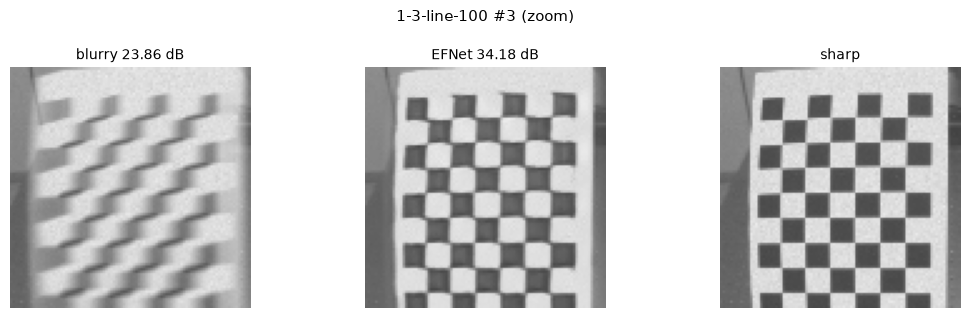

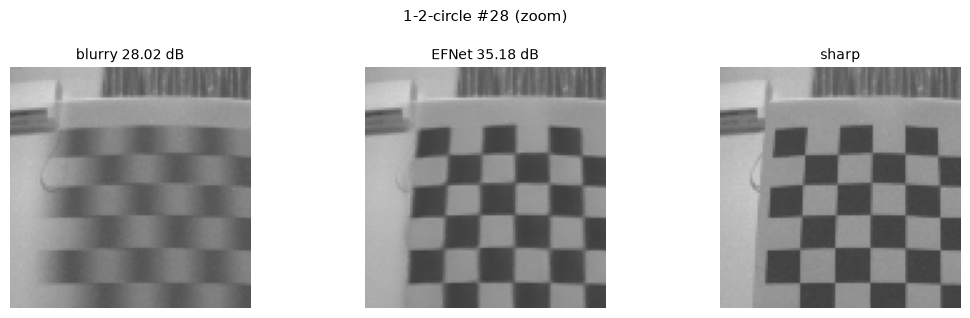

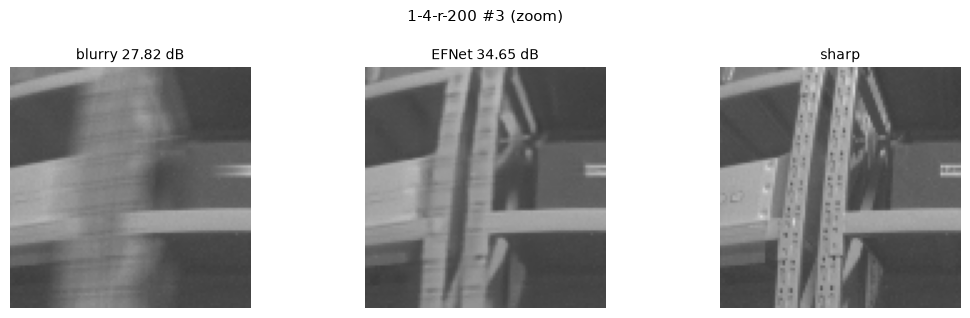

In [8]:
device = pick_device()
model = load_efnet(WEIGHTS, device)
print(f"EFNet on {device}: {sum(p.numel() for p in model.parameters()):,} parameters")

efnet_out = [efnet_deblur(model, d["blurry"], d["scer"], d["mask"], device) for d in data]
for r, (d, crop) in enumerate(zip(data, crops)):
    show_images([d["blurry"], efnet_out[r], d["sharp"]],
                [f"blurry {psnr(d['blurry'], d['sharp']):.2f} dB", f"EFNet {psnr(efnet_out[r], d['sharp']):.2f} dB", "sharp"],
                crop=crop, suptitle=f"{SAMPLES[r][0]} #{SAMPLES[r][1]} (zoom)"); plt.show()

## 6. Comparison on the REBlur test split

`evaluate_reblur` (`evcam/deblur_eval.py`) computes PSNR and SSIM against ground truth for every method on all 903 test samples; CMax + RL runs on every 8th sample (113 frames) because it takes about 5 s per frame, and EDI is also run with one fixed `c` fitted on the train split. 

$$\text{PSNR} = 10 \log_{10} \frac{\text{MAX}^2}{\frac{1}{N}\sum_{\mathbf{x}} \big(\hat{L}(\mathbf{x}) - L(\mathbf{x})\big)^2}$$

$\hat{L}$: deblurred frame, $L$: ground-truth sharp frame, $N$: number of pixels, $\text{MAX} = 1$: intensity range.

In [9]:
FIXED_C, cs_train, psnr_train = fit_fixed_c("train")     # one global c, fitted on the TRAIN split
print(f"best single c on the train split: {FIXED_C:.3f} ({psnr_train.max():.2f} dB there)")

CMAX_EVERY = 8      # CMax + RL takes ~5 s per frame, so it runs on every 8th test sample
res = evaluate_reblur(model, device, FIXED_C, split="test", cmax_every=CMAX_EVERY)   # cached in data/reblur/eval_test.npz

best single c on the train split: 0.125 (35.61 dB there)


In [10]:
PAPER = {"edi_selected": (36.52, 0.964), "efnet": (38.12, 0.975)}      # EFNet paper (Sun et al. 2022), Table 3
ROWS = [("blurry", "Blurry input"), ("cmax_rl", "CMax + RL"), ("edi_selected", "EDI, selected c (GT-free)"),
        ("edi_fixed", f"EDI, fixed c = {FIXED_C:.3f} (from train)"), ("edi_oracle", "EDI, ORACLE c (uses GT)"),
        ("efnet", "EFNet, stored SCER"), ("efnet_own_scer", "EFNet, our SCER + mask")]
sub = ~np.isnan(res["psnr"]["cmax_rl"])

print(f"{'method':38s} {'full test split (' + str(len(sub)) + ')':>22s} {'CMax subset (' + str(sub.sum()) + ')':>20s} {'paper':>15s}")
print(f"{'':38s} {'PSNR':>12s} {'SSIM':>9s} {'PSNR':>10s} {'SSIM':>9s} {'PSNR':>8s} {'SSIM':>6s}")
for key, name in ROWS:
    P, S = res["psnr"][key], res["ssim"][key]
    full = f"{P.mean():12.2f} {S.mean():9.4f}" if key != "cmax_rl" else f"{'-':>12s} {'-':>9s}"
    paper = f"{PAPER[key][0]:8.2f} {PAPER[key][1]:6.3f}" if key in PAPER else f"{'-':>8s} {'-':>6s}"
    print(f"{name:38s} {full} {P[sub].mean():10.2f} {S[sub].mean():9.4f} {paper}")

print(f"\nselected c: mean {res['c_selected'].mean():.3f}, at the lower bound (0.05) in {np.mean(res['c_selected'] < 0.055):.0%} of samples")
print(f"oracle c:   mean {res['c_oracle'].mean():.3f}; correlation between selected and oracle c: "
      f"{np.corrcoef(res['c_selected'], res['c_oracle'])[0, 1]:.2f}")

method                                  full test split (903)    CMax subset (113)           paper
                                               PSNR      SSIM       PSNR      SSIM     PSNR   SSIM
Blurry input                                  34.31    0.9523      34.33    0.9521        -      -
CMax + RL                                         -         -      34.88    0.9548        -      -
EDI, selected c (GT-free)                     34.71    0.9561      34.73    0.9559    36.52  0.964
EDI, fixed c = 0.125 (from train)             35.01    0.9576      35.04    0.9575        -      -
EDI, ORACLE c (uses GT)                       35.42    0.9587      35.44    0.9584        -      -
EFNet, stored SCER                            38.07    0.9748      38.05    0.9747    38.12  0.975
EFNet, our SCER + mask                        38.07    0.9749      38.06    0.9748        -      -

selected c: mean 0.060, at the lower bound (0.05) in 90% of samples
oracle c:   mean 0.122; correlation betw

Plots the per-sample PSNR gain over the blurry input for each method, and the selected $c$ against the oracle $c$.

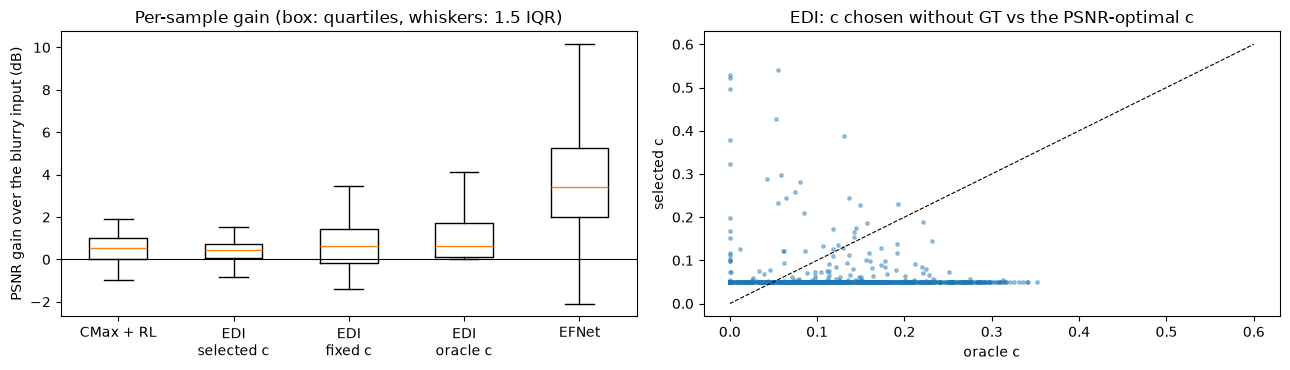

In [11]:
gain = {k: res["psnr"][k] - res["psnr"]["blurry"] for k, _ in ROWS[1:]}
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
keys = ["cmax_rl", "edi_selected", "edi_fixed", "edi_oracle", "efnet"]
ax[0].boxplot([gain[k][~np.isnan(gain[k])] for k in keys], showfliers=False)
ax[0].set_xticks(range(1, len(keys) + 1)); ax[0].set_xticklabels(["CMax + RL", "EDI\nselected c", "EDI\nfixed c", "EDI\noracle c", "EFNet"])
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_ylabel("PSNR gain over the blurry input (dB)")
ax[0].set_title("Per-sample gain (box: quartiles, whiskers: 1.5 IQR)")
ax[1].scatter(res["c_oracle"], res["c_selected"], s=6, alpha=0.4)
ax[1].plot([0, 0.6], [0, 0.6], "k--", lw=0.8); ax[1].set_xlabel("oracle c"); ax[1].set_ylabel("selected c")
ax[1].set_title("EDI: c chosen without GT vs the PSNR-optimal c")
plt.tight_layout(); plt.show()

### Zoomed crops, same region for every method

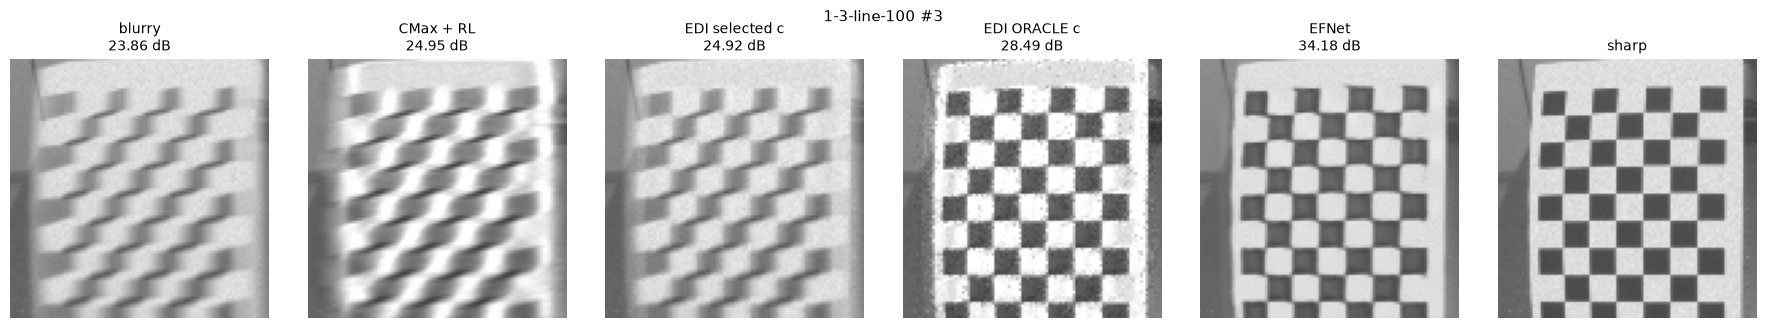

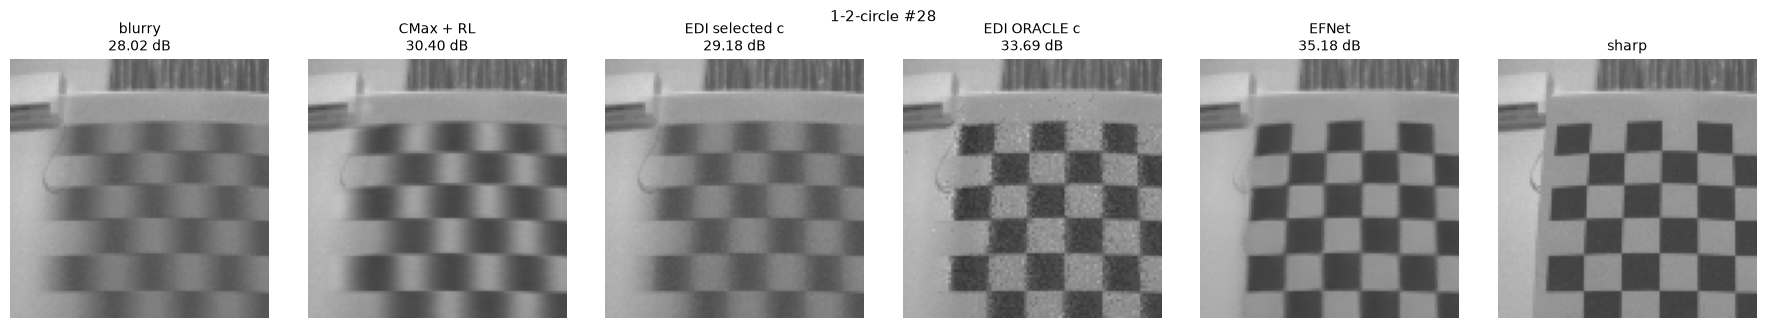

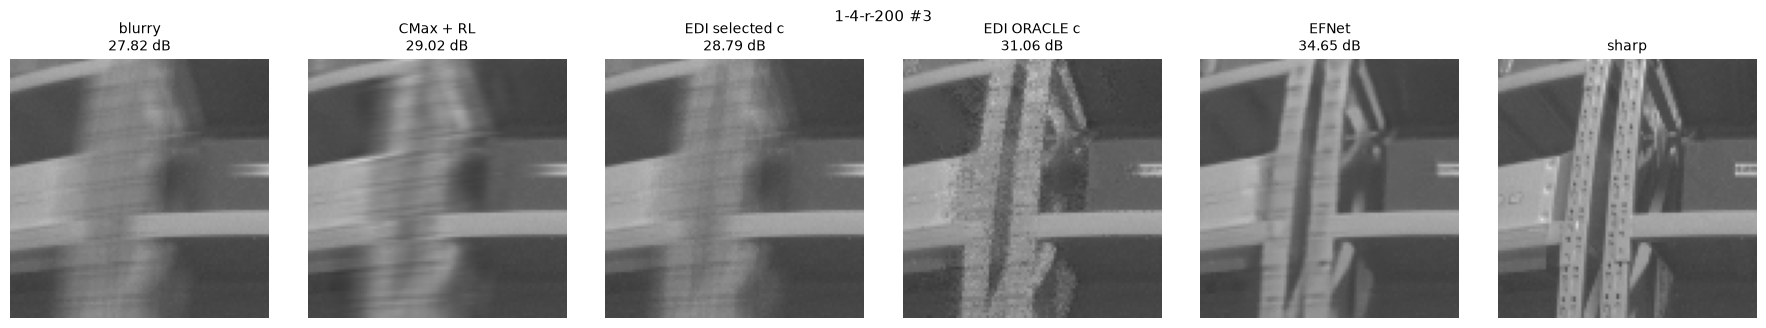

In [12]:
for r, (d, crop) in enumerate(zip(data, crops)):
    imgs = [d["blurry"], cmax_out[r], edi_sel[r], edi_orc[r], efnet_out[r], d["sharp"]]
    names = ["blurry", "CMax + RL", "EDI selected c", "EDI ORACLE c", "EFNet", "sharp"]
    titles = [n if n == "sharp" else f"{n}\n{psnr(im, d['sharp']):.2f} dB" for n, im in zip(names, imgs)]
    show_images(imgs, titles, crop=crop, figsize_per=(3.0, 3.3), suptitle=f"{SAMPLES[r][0]} #{SAMPLES[r][1]}"); plt.show()

### Failure modes, as observed

## 7. Own data (placeholder)

Runs EDI and EFNet (with our own SCER) on one frame from our DAVIS346, without ground truth. The cell currently skips: the frames in `digit4.aedat4` are DV Accumulator output, not APS frames, and the cell runs as is once a recording with real APS frames is available.

In [13]:
# PLACEHOLDER: own DAVIS346 data. Runs only if the recording holds real APS frames.
OWN_RECORDING = "data/digit4.aedat4"

if not os.path.exists(OWN_RECORDING):
    print(f"SKIPPED: {OWN_RECORDING} not found.")
else:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")          # the loader's own accumulator warning; reported below instead
        own_events, own_frames, own_size = load_aedat4(OWN_RECORDING)
    accumulated, why = frames_look_accumulated(own_frames)
    t_first, t_last = own_events["t"][0], own_events["t"][-1]
    usable = [f for f in own_frames if f["exposure_begin_t"] >= t_first and f["exposure_end_t"] <= t_last]

    if accumulated or not usable:
        print(f"SKIPPED: {OWN_RECORDING} has no usable APS frames.")
        print(f"  frame check: {why['summary']}")
        print("  These frames are DV Accumulator output (images rendered from the events), so EDI and EFNet")
        print("  would be deblurring an image made of the very events they use. Re-record with the camera's")
        print("  `frames` output wired to the file output, set OWN_RECORDING, and this cell runs as is.")
    else:
        # the frame with the most events during its exposure, among those fully inside the event stream
        count = lambda f: np.searchsorted(own_events["t"], f["exposure_end_t"]) - np.searchsorted(own_events["t"], f["exposure_begin_t"])
        f = max(usable, key=count)
        blurry = f["image"].astype(np.float64) / 255.0
        tb, te = f["exposure_begin_t"], f["exposure_end_t"]

        c_own, _ = edi_select_c(blurry, own_events, tb, te)
        own_edi = edi_deblur(blurry, own_events, tb, te, c_own)
        own_scer = scer(own_events, tb, te, blurry.shape)                      # our SCER, validated in section 2
        own_efnet = efnet_deblur(model, blurry, own_scer, scer_mask(own_scer), device)

        print(f"frame at t = {f['t'] / 1e6:.3f} s, exposure {(te - tb) / 1e3:.1f} ms, {count(f):,} events")
        show_images([blurry, own_edi, own_efnet], ["blurry APS frame", f"EDI (selected c = {c_own:.3f})", "EFNet (our SCER)"],
                    figsize_per=(5, 4), suptitle="Own data: qualitative only, no ground truth"); plt.show()

SKIPPED: data/digit4.aedat4 has no usable APS frames.
  frame check: 41% of non-saturated pixels sit on 3 grey values; exposure equals the frame period, 33.0 ms
  These frames are DV Accumulator output (images rendered from the events), so EDI and EFNet
  would be deblurring an image made of the very events they use. Re-record with the camera's
  `frames` output wired to the file output, set OWN_RECORDING, and this cell runs as is.


## 8. Summary